<a href="https://colab.research.google.com/github/debarshichoudhury25/Floquet-system-and-kicked-rotor-model-in-many-body-chaos/blob/main/2D_kicked_rotor_lattice_kinetic_energy_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simulating K = 0.1
Simulating K = 0.2
Simulating K = 0.3
Simulating K = 0.4
Simulating K = 0.5


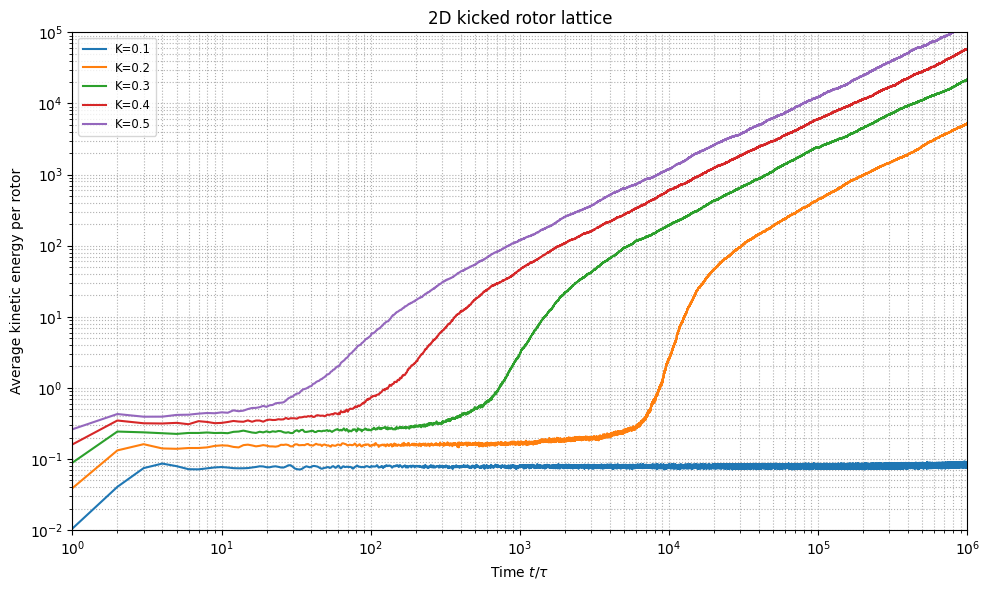

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter

N = 20                  # Lattice side length
tau = 1.0
timesteps = 1000000
K_list = [0.1, 0.2, 0.3, 0.4, 0.5]
samples = 5

def simulate_one(K, N, tau, timesteps):
    kappa = K / tau
    phi = np.random.uniform(0, 2*np.pi, (N, N))  # angles (N x N array)
    p = np.zeros((N, N))                         # momenta (N x N array)
    E_kin = np.zeros(timesteps)
    for t in range(timesteps):
        # RIGHT bonds
        phi_right = np.roll(phi, -1, axis=1)      # wrap to first column
        delta_right = phi - phi_right
        s_right = np.sin(delta_right)

        p += -kappa * s_right                     # impulse to site A
        p += np.roll(+kappa * s_right, 1, axis=1) # impulse to site B

        # UP bonds (periodic in y)
        phi_up = np.roll(phi, -1, axis=0)         # wrap to first row
        delta_up = phi - phi_up
        s_up = np.sin(delta_up)

        p += -kappa * s_up
        p += np.roll(+kappa * s_up, 1, axis=0)


        phi = (phi + p * tau) % (2 * np.pi)

        E_kin[t] = np.mean(0.5 * p**2)

    return E_kin


plt.figure(figsize=(10, 6))
time_array = np.arange(1, timesteps+1)  # start from 1 to avoid log(0)

for K in K_list:
    print(f"Simulating K = {K}")
    E_accum = np.zeros(timesteps)
    for s in range(samples):
        E_accum += simulate_one(K, N, tau, timesteps)
    E_avg = E_accum / samples  # average over different K.E

    plt.plot(time_array, E_avg, label=f"K={K}")

# Plotting
plt.xscale("log")
plt.yscale("log")
plt.xlim(1, 1e6)
plt.ylim(1e-2, 1e5)
plt.xlabel(r"Time $t/\tau$")
plt.ylabel(r"Average kinetic energy per rotor")
plt.title(f"2D kicked rotor lattice")
plt.legend(fontsize='small')
plt.grid(True, which="both", ls=":")
plt.tight_layout()
plt.show()
